In [1]:
import os
from pathlib import Path

root_is_cwd = os.getcwd().endswith("fusionLearning")

if not root_is_cwd:
    os.chdir(Path().resolve().parent.parent)
    print("Changed to root directory")
    root_is_cwd = True
else:
    print("Already in root directory")

print(os.getcwd())

Changed to root directory
C:\Users\GAMER01\codeproj\fusionLearning\fusionLearning


In [2]:
from models.consts import MAXEPOCHS, BATCHSIZE, MOMENTUM, LEARNING_RATE, NUM_CLASSES

In [3]:
import torch 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Declare model type and encoder architecture
 
### Available encoders are listed [here](https://smp.readthedocs.io/en/latest/encoders.html) in SMP's documentation

| Type | Names |
| --- | --- |
| VGG | ```vgg16```  ```vgg19``` |
| ResNet | ```resnet18``` ```resnet34``` ```resnet50``` ```resnet101``` ```resnet152``` |
| SE-ResNet | ```seresnet18``` ```seresnet34``` ```seresnet50``` ```seresnet101``` ```seresnet152``` |
| ResNeXt | ```resnext50``` ```resnext101``` |
| SE-ResNeXt | ```seresnext50``` ```seresnext101``` |
| SENet154 | ```senet154``` |
| DenseNet | ```densenet121``` ```densenet109``` ```densenet201``` |
| Inception | ```inceptionv3``` ```inceptionresnetv2``` |
| MobileNet | ```mobilenet``` ```mobilenetv2``` |
| EfficientNet | ```efficientnetb0``` ```efficientnetb1``` ```efficientnetb2``` ```efficientnetb3``` ```efficientnetb4``` ```efficientnetb5``` ```efficientnetb6``` ```efficientnetb7``` |

In [4]:
encoder = "resnet18"

In [5]:
import segmentation_models_pytorch as smp 

#CHANGE THIS: model = smp.{model}()
model = smp.Unet(
    encoder_name=encoder,  
    encoder_weights=None,  
    in_channels=3,  
    classes=NUM_CLASSES,
).to(device)

optimizer = torch.optim.SGD(model.parameters(),
                           lr=LEARNING_RATE,
                           momentum=MOMENTUM)

lossFunc = torch.nn.BCEWithLogitsLoss()


c:\Users\GAMER01\codeproj\fusionLearning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
from config import CUB, CUB_IMAGES, CUB_SEGMENTATIONS

path_images_folder = os.path.join(CUB_IMAGES)
path_segmentations_folder = os.path.join(CUB_SEGMENTATIONS)

print(path_images_folder)
print(path_segmentations_folder)

C:\Users\GAMER01\codeproj\fusionLearning\fusionLearning\data\CUBdata\CUB_200_2011\images
C:\Users\GAMER01\codeproj\fusionLearning\fusionLearning\data\CUBdata\segmentations


In [7]:
from data.dataloaders import create_train_val_test_loaders
from data.aug import geoTransforms, photometricTransforms


training_dataloader, validation_dataloader, test_dataloader = create_train_val_test_loaders(
    path_images_folder,
    path_segmentations_folder,
    batch_size=BATCHSIZE,
    train_ratio=0.7,
    val_ratio=0.2,
    gTransforms=geoTransforms,                   # to change later
    pTransforms=photometricTransforms            # to change later
)
    

Dataset loaded with 11788 image-segmentation pairs


In [8]:
"""

import time

delta = 0.5
debug_vis = False

for i, (image, segmentation_mask, _) in enumerate(test_dataloader):

    if debug_vis:
        print(f"Image shape: {image.shape}")
        print(f"Segmentation mask shape: {segmentation_mask.shape}")

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image.squeeze().permute(1,2,0))
    ax[1].imshow(segmentation_mask.squeeze())
    plt.ion()
    plt.show()
    plt.pause(delta)
    plt.cla()

"""

'\n\nimport time\n\ndelta = 0.5\ndebug_vis = False\n\nfor i, (image, segmentation_mask, _) in enumerate(test_dataloader):\n\n    if debug_vis:\n        print(f"Image shape: {image.shape}")\n        print(f"Segmentation mask shape: {segmentation_mask.shape}")\n\n    fig, ax = plt.subplots(1, 2, figsize=(10, 5))\n    ax[0].imshow(image.squeeze().permute(1,2,0))\n    ax[1].imshow(segmentation_mask.squeeze())\n    plt.ion()\n    plt.show()\n    plt.pause(delta)\n    plt.cla()\n\n'

In [9]:
import matplotlib.pyplot as plt

def visualize_training_process(metrics):
    """Visualize the final training process metrics"""
    plt.figure(figsize=(8, 5))
    plt.plot(metrics['epochs'], metrics['train_loss'], 'bo-', label='Training Loss')
    plt.plot(metrics['epochs'], metrics['val_loss'], 'ro-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("outputs/final_training_metrics.png")
    plt.close()


In [10]:
DEBUG_TRAIN = False

In [11]:


from tqdm import tqdm
import os
import json
from torchmetrics.classification import BinaryAUROC
# !!! TODO: Fix ROC AUC metric calculation in validation phase

def train(modelDir):
    output_dir = modelDir + "outputs"
    os.makedirs(output_dir, exist_ok=True)
    metrics_path = os.path.join(output_dir, "epoch_metrics.json")
    # Initialize metrics file
    with open(metrics_path, 'w') as f:
        json.dump([], f)

    best_val_loss = float('inf')
    val_auc_metric = BinaryAUROC(thresholds=32).to(device)

    for epoch in range(1, MAXEPOCHS + 1):
        # --- Training Phase ---
        model.train()
        train_loss = 0.0
        for images, masks, _ in tqdm(training_dataloader, desc=f"Epoch {epoch}/{MAXEPOCHS} [Train]", leave=False, ncols=80):


            if DEBUG_TRAIN:
                print("images shape:", images.shape)
                print("images dtype:", images.dtype)
                print("images device:", images.device)

                print("masks shape:", masks.shape)
                print("masks dtype:", masks.dtype)
                print("masks device:", masks.device)

                print("device:", device)


            images = images.contiguous().to(device)
            masks  = masks.contiguous().to(device)
            
            if DEBUG_TRAIN:
                print("mask unique values:", torch.unique(masks))
                print("mask dtype:", masks.dtype)
                print("mask shape:", masks.shape)


            optimizer.zero_grad()
            logits = model(images)
            loss = lossFunc(logits, masks)

            if DEBUG_TRAIN:
                print(f"logits: {logits.shape}, dtype: {logits.dtype}, device: {logits.device}")
                print(f"masks: {masks.shape}, dtype: {masks.dtype}, device: {masks.device}")

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        avg_train_loss = train_loss / len(training_dataloader)
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        val_auc_metric.reset()
        with torch.no_grad():
            for images, masks, _ in tqdm(validation_dataloader, desc=f"Epoch {epoch}/{MAXEPOCHS} [Val]", leave=False, ncols=80):
                images = images.to(device)
                masks  = masks.to(device)
                logits = model(images)
                val_loss += lossFunc(logits, masks).item()

                # Ensure correct shape and type for ROC AUC
                probs = torch.sigmoid(logits).reshape(-1)
                targets = masks.reshape(-1)
                val_auc_metric.update(probs, targets)

        avg_val_loss = val_loss / len(validation_dataloader)
        val_auc = val_auc_metric.compute().item()

        # Learning rate -- maybe swap to scheduler for higher convergence
        lr = LEARNING_RATE

        # save to .pth
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), os.path.join(output_dir, 'best_model.pth'))

        # write to jason
        with open(metrics_path, 'r+') as f:
            data = json.load(f)
            data.append({
                'epoch': epoch,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'val_auc': val_auc,
                'lr': lr
            })
            f.seek(0)
            json.dump(data, f, indent=2)
            f.truncate()

        print(f"Epoch {epoch:2d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} "
              f"| Val AUC: {val_auc:.4f} | LR: {lr:.6f}")

    print(f"Training complete. Metrics written to {metrics_path}")


In [12]:

def test(modelDir):
    model.eval()
    tloss = 0.0

    with torch.no_grad():
        for image, segmentation_mask, _ in tqdm(test_dataloader, desc=f"[TEST]", leave=False, ncols=80):
            image = image.to(device)
            segmentation_mask = segmentation_mask.to(device)

            logits = model(image)
            tloss += lossFunc(logits, segmentation_mask).item()

    avg_test_loss = tloss / len(test_dataloader)

    test_metrics = {
        'test_loss': avg_test_loss,
    }
    with open(modelDir + 'outputs/test_metrics.json', 'w') as f:
        json.dump(test_metrics, f)

    print(f"Test: Loss={avg_test_loss:.4f}")
    return test_metrics

In [13]:
import matplotlib.pyplot as plt
import json

def plot_metrics(modelDir):
    with open(modelDir + "outputs/epoch_metrics.json", 'r') as f:
        data = json.load(f)
    epochs = [d['epoch'] for d in data]
    train_loss = [d['train_loss'] for d in data]
    val_loss = [d['val_loss'] for d in data]
    val_auc = [d['val_auc'] for d in data]
    lr = [d['lr'] for d in data]
    plt.figure(figsize=(12, 8))
    plt.subplot(2,1,1)
    plt.plot(epochs, train_loss, 'b-', label='Train Loss')
    plt.plot(epochs, val_loss, 'r-', label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(2,1,2)
    plt.plot(epochs, val_auc, 'r-', label='Validation ROC AUC')
    plt.xlabel('Epoch')
    plt.ylabel('Validation ROC AUC')
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(modelDir + "outputs/final_training_metrics.png")
    plt.show()

In [14]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [15]:
torch.cuda.is_available()

True

In [16]:
import torch

device = torch.device("cuda")

try:
    images = torch.randn(1, 3, 352, 512, device=device)
    masks = torch.randint(0, 2, (1, 352, 512), dtype=torch.int64, device=device)
    print("Tensors created and moved to CUDA successfully")
except RuntimeError as e:
    print("RuntimeError:", e)



Tensors created and moved to CUDA successfully


In [17]:

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
os.environ["TORCH_USE_CUDA_DSA"] = "1"

import torch
torch.cuda.empty_cache()



## Edit below hard links to point at model directory

### First, edit modelDir and modelName
### Then, change model declaration to model = smp.{modelName}

Model already trained. To retrain, delete the 'outputs/best_model.pth' file.
 Going ahead with testing...


Test: Loss=0.2478

Testing completed successfully.


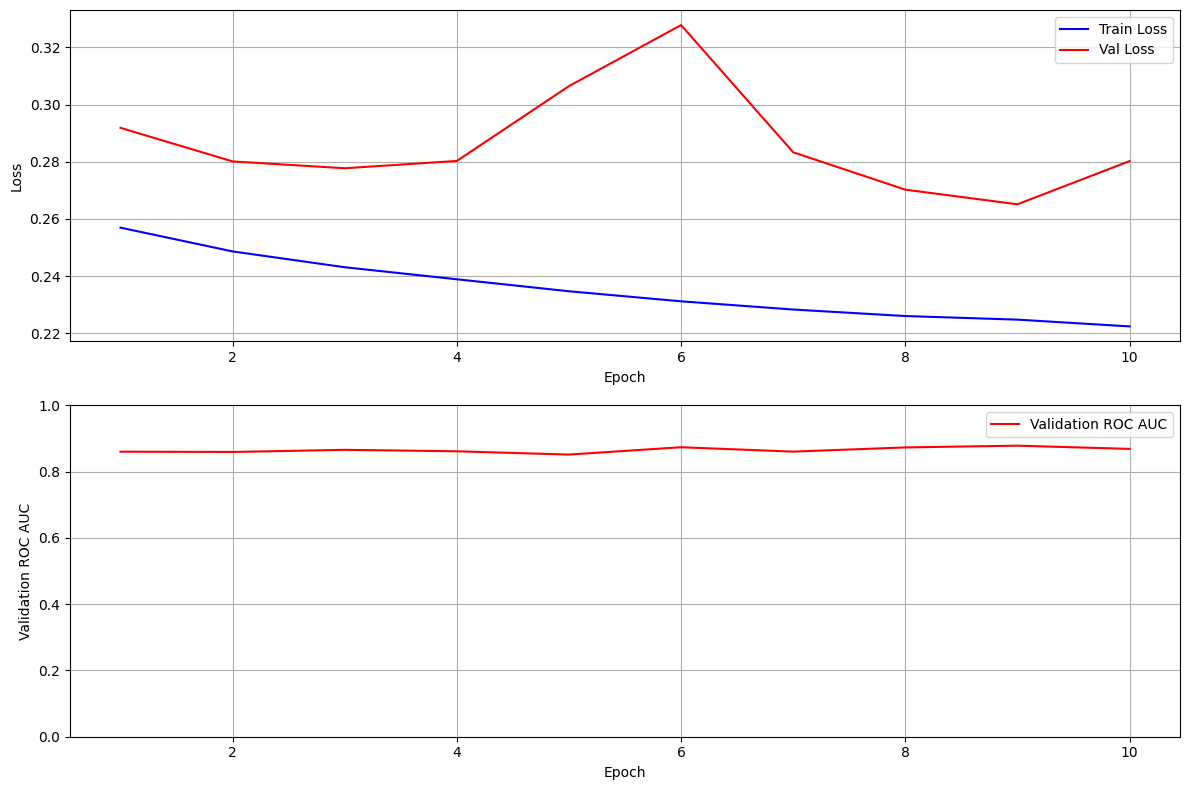

In [18]:

import sys

# EDIT BELOW
modelDir = "models/Unet_resnet18/"
modelName = "Unet_resnet18"
modified = True

# Create outputs directory if it doesn't exist
os.makedirs(modelDir + "outputs", exist_ok=True)

if not modified:
    sys.exit("TODO: Modify modelDir and modelName")

if os.path.exists(modelDir + "outputs/best_model.pth"):
    print("Model already trained. To retrain, delete the 'outputs/best_model.pth' file.\n Going ahead with testing...")

    # Load best model -- EDIT BELOW

    model = smp.Unet(
        encoder_name=encoder,  
        encoder_weights=None,  
        in_channels=3,  
        classes=NUM_CLASSES,
    )
    model.load_state_dict(torch.load(modelDir + f"outputs/best_model.pth"))
    model.to(device)

    test_metrics = test(modelDir)
    print("\nTesting completed successfully.")
    plot_metrics(modelDir)
else:
    if device.type == "cuda":
        print("Starting training process...")
        train(modelDir)
        print("\nStarting testing process...")
        test_metrics = test(modelDir)
        print("\nTraining and testing completed lsuccessfully.")
        print("\t * Results and visualizations saved in the 'outputs' directory. * ")

        plot_metrics(modelDir)

    else:
        print("No GPU available, exiting...")

In [19]:
import pprint
import random



def inference_from_paths(model, modelDir, test_dataloader, n=5):
    # limit to 50 samples
    """
    Samples n random datapoints from the test set using the underlying dataset's image paths,
    loads and visualizes both the true and predicted segmentation masks.
    """


    # Try to access the dataset object and its image paths
    dataset = test_dataloader.dataset
    if hasattr(dataset, 'dataset'):
        # This is a Subset, get the original dataset
        base_dataset = dataset.dataset
        indices = dataset.indices
        image_paths = [base_dataset.image_paths[i] for i in indices]
    else:
        image_paths = dataset.image_paths

    total_samples = len(image_paths)
    n = min(n, 50)                                          
    indices = random.sample(range(total_samples), n)


    model.to(device)
    model.load_state_dict(torch.load(modelDir + "outputs/best_model.pth", map_location=device))
    model.eval()
    
    fns = []
    plt.figure(figsize=(6, n * 3))
    for i, idx in enumerate(indices):
        

        # Get sample from dataset by index
        image, true_mask, filename = dataset[idx]
        fns.append(filename)
        image_input = image.to(device).unsqueeze(0)  # think indexing the test dataset doesnt apply transforms
        true_mask_np = true_mask.cpu().squeeze(0).numpy()

        with torch.no_grad():
            logits = model(image_input)
            pred_mask = torch.argmax(logits, dim=1)[0].cpu().numpy()

        pred_mask = (pred_mask > 0).astype(int)  # this should fix the issue

        plt.subplot(n, 3, i * 3 + 1)
        plt.imshow(image.cpu().permute(1, 2, 0))
        plt.title(f"Sample {i+1}")
        plt.axis('off') 

        plt.subplot(n, 3, i * 3 + 2)
        plt.imshow(true_mask_np, cmap='gray')
        plt.title(f"True Mask")
        plt.axis('off') 

        plt.subplot(n, 3, i * 3 + 3)
        plt.imshow(pred_mask, cmap='gray')
        plt.title(f"Predicted Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.savefig(modelDir + "outputs/inference.png")
    plt.show()

    plt.close()

    pprint.pprint(fns)


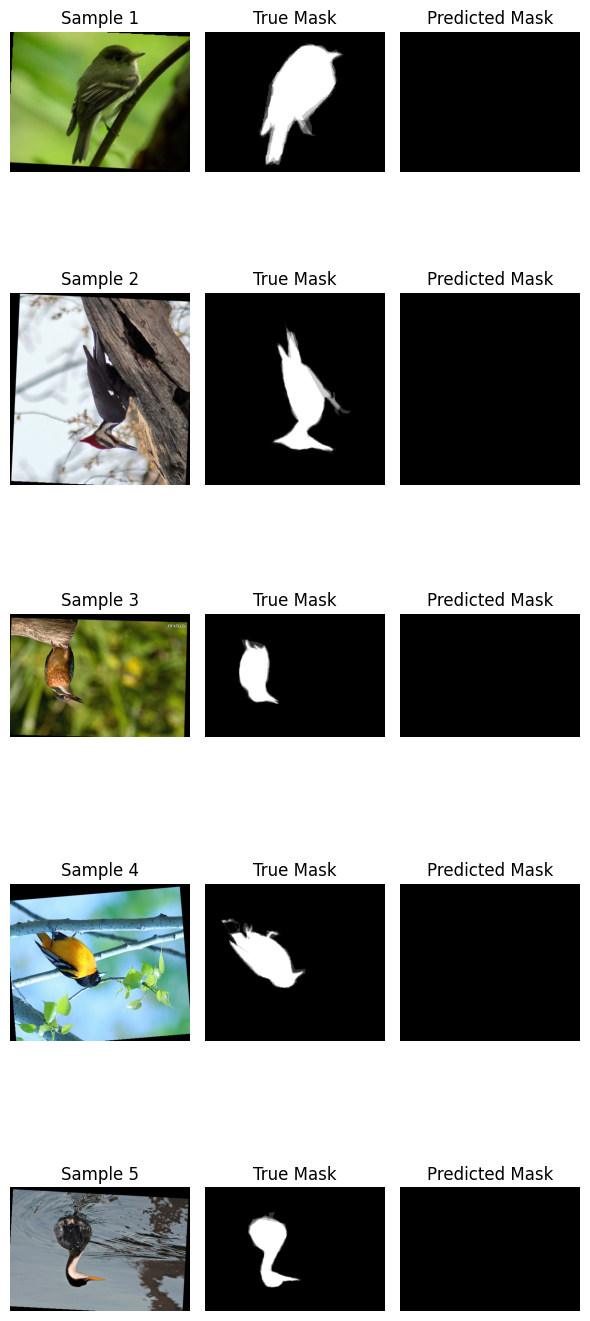

['Acadian_Flycatcher_0004_795623.jpg',
 'Pileated_Woodpecker_0125_179971.jpg',
 'Green_Kingfisher_0045_71064.jpg',
 'Baltimore_Oriole_0045_88178.jpg',
 'Western_Grebe_0034_36149.jpg']


In [20]:


model = smp.Unet(
    encoder_name= encoder,  
    encoder_weights=None,  
    in_channels=3,  
    classes=NUM_CLASSES,
)


inference_from_paths(model=model, modelDir="models/Unet_resnet18/", test_dataloader=test_dataloader, n=5)

In [21]:
def copy_best_model_to_weights(model_dir):
    """
    Copies the best model from the model's output directory to the weights directory.
    """
    src = os.path.join(model_dir, "outputs", "best_model.pth")
    dst = os.path.join(model_dir, "..", "..", "weights", "linknet.pth")
    shutil.copy(src, dst)

copy_best_model_to_weights("models/linknet/")

NameError: name 'shutil' is not defined